# Lectura de datos


obejtivo: Desarrollar un modelo de Machine Learning de clasificación multiclase que prediga la situación del estudiante, combinando información académica y psicosocial.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#%matplotlib inline

In [74]:
# Leer datasets académico y psicosocial
df_acad = pd.read_csv('5.dataset_academico.csv', sep=',')
df_psico = pd.read_csv('5.dataset_psicosocial.csv', sep=',')

In [75]:
# Combinar datasets por id_estudiante
df = pd.merge(df_acad, df_psico, on='id_estudiante', how='inner')

# Vista inicial
print('Dimensiones:', df.shape)
print('Columnas:', df.columns.tolist())
df.head()

Dimensiones: (3000, 36)
Columnas: ['id_estudiante', 'edad', 'grado', 'promedio_matematica', 'promedio_comunicacion', 'promedio_ciencias', 'promedio_general', 'num_cursos_desaprobados', 'porcentaje_asistencia', 'num_tardanzas', 'num_inasistencias_injustificadas', 'tendencia_notas', 'participacion_clase', 'entrega_tareas', 'repitio_grado', 'horas_estudio_semanal', 'target', 'genero', 'estructura_familiar', 'num_hermanos', 'nivel_socioeconomico', 'nivel_educativo_padres', 'trabaja_estudiante', 'horas_trabajo_semanal', 'acceso_internet_hogar', 'distancia_colegio_km', 'nivel_autoestima', 'nivel_ansiedad', 'nivel_motivacion_escolar', 'apoyo_familiar_percibido', 'eventos_estresantes_recientes', 'relacion_con_companeros', 'horas_sueño_diarias', 'consumo_sustancias', 'participa_actividades_extracurriculares', 'atencion_psicologica_previa']


,id_estudiante,edad,grado,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,...,nivel_autoestima,nivel_ansiedad,nivel_motivacion_escolar,apoyo_familiar_percibido,eventos_estresantes_recientes,relacion_con_companeros,horas_sueño_diarias,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa
0,3169,16.0,5,10.85,14.06,12.30,13.37,0,77.5,6,...,5.0,1,4,4,0,Regular,7.2,0,1,1
1,1163,15.0,3,18.63,14.59,16.66,17.37,0,100.0,1,...,3.0,2,5,3,0,Regular,7.9,0,0,0
2,2517,13.0,2,20.00,16.54,14.42,16.74,0,98.5,2,...,3.0,2,5,4,0,Regular,6.7,0,0,0
3,2318,13.0,1,16.91,19.40,19.70,18.24,1,95.4,1,...,5.0,2,3,3,0,Buena,5.2,0,1,0
4,1686,17.0,5,17.83,13.27,14.91,15.59,0,87.4,2,...,4.0,2,3,4,0,Buena,6.8,0,1,0


In [76]:
# Información general del dataset
df.info()
print('\n')
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id_estudiante                            3000 non-null   int64  
 1   edad                                     3000 non-null   float64
 2   grado                                    3000 non-null   int64  
 3   promedio_matematica                      3000 non-null   float64
 4   promedio_comunicacion                    3000 non-null   float64
 5   promedio_ciencias                        2910 non-null   float64
 6   promedio_general                         3000 non-null   float64
 7   num_cursos_desaprobados                  3000 non-null   int64  
 8   porcentaje_asistencia                    2940 non-null   float64
 9   num_tardanzas                            3000 non-null   int64  
 10  num_inasistencias_injustificadas         3000 non-null   in

,id_estudiante,edad,grado,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,...,distancia_colegio_km,nivel_autoestima,nivel_ansiedad,nivel_motivacion_escolar,apoyo_familiar_percibido,eventos_estresantes_recientes,horas_sueño_diarias,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2910.000000,3000.000000,3000.000000,2940.000000,3000.000000,...,2940.000000,2910.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2500.500000,14.462667,2.958333,12.209660,12.295623,12.389969,12.312043,1.882000,78.370748,4.870000,...,2.777956,3.040550,3.080000,2.918667,3.143667,0.368667,6.633033,0.086667,0.385667,0.236667
std,866.169729,1.550723,1.412774,4.058927,4.087180,4.126823,3.605354,1.768932,12.408769,3.554431,...,3.381443,1.051643,1.081661,1.107156,1.105185,0.482524,1.221560,0.281393,0.486834,0.425107
min,1001.000000,6.000000,1.000000,0.000000,0.000000,0.000000,2.140000,0.000000,31.600000,0.000000,...,0.100000,1.000000,1.000000,1.000000,1.000000,0.000000,0.600000,0.000000,0.000000,0.000000
25%,1750.750000,13.000000,2.000000,9.237500,9.400000,9.480000,9.617500,0.000000,69.900000,2.000000,...,0.730000,2.000000,2.000000,2.000000,2.000000,0.000000,5.800000,0.000000,0.000000,0.000000
50%,2500.500000,14.000000,3.000000,12.240000,12.355000,12.490000,12.395000,2.000000,78.700000,4.000000,...,1.860000,3.000000,3.000000,3.000000,3.000000,0.000000,6.700000,0.000000,0.000000,0.000000
75%,3250.250000,16.000000,4.000000,15.212500,15.400000,15.520000,15.160000,3.000000,87.725000,7.000000,...,3.760000,4.000000,4.000000,4.000000,4.000000,1.000000,7.500000,0.000000,1.000000,0.000000
max,4000.000000,30.000000,5.000000,20.000000,20.000000,20.000000,20.000000,9.000000,112.700000,57.000000,...,59.190000,5.000000,5.000000,5.000000,5.000000,1.000000,11.200000,1.000000,1.000000,1.000000


In [77]:
# Cantidad de valores nulos por columna
df.isnull().sum()

id_estudiante                                 0
edad                                          0
grado                                         0
promedio_matematica                           0
promedio_comunicacion                         0
promedio_ciencias                            90
promedio_general                              0
num_cursos_desaprobados                       0
porcentaje_asistencia                        60
num_tardanzas                                 0
num_inasistencias_injustificadas              0
tendencia_notas                             120
participacion_clase                           0
entrega_tareas                              150
repitio_grado                                 0
horas_estudio_semanal                       180
target                                        0
genero                                        0
estructura_familiar                           0
num_hermanos                                  0
nivel_socioeconomico                    

# EDA de datos


C:\Users\yerym\AppData\Local\Temp\ipykernel_26348\3243718063.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


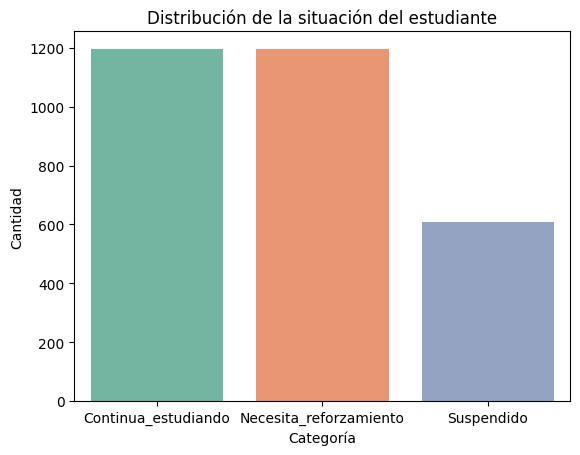

In [78]:
# Distribución de la variable objetivo
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribución de la situación del estudiante')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')
plt.show()

> La distribución del target muestra si existe desbalanceo entre las clases.


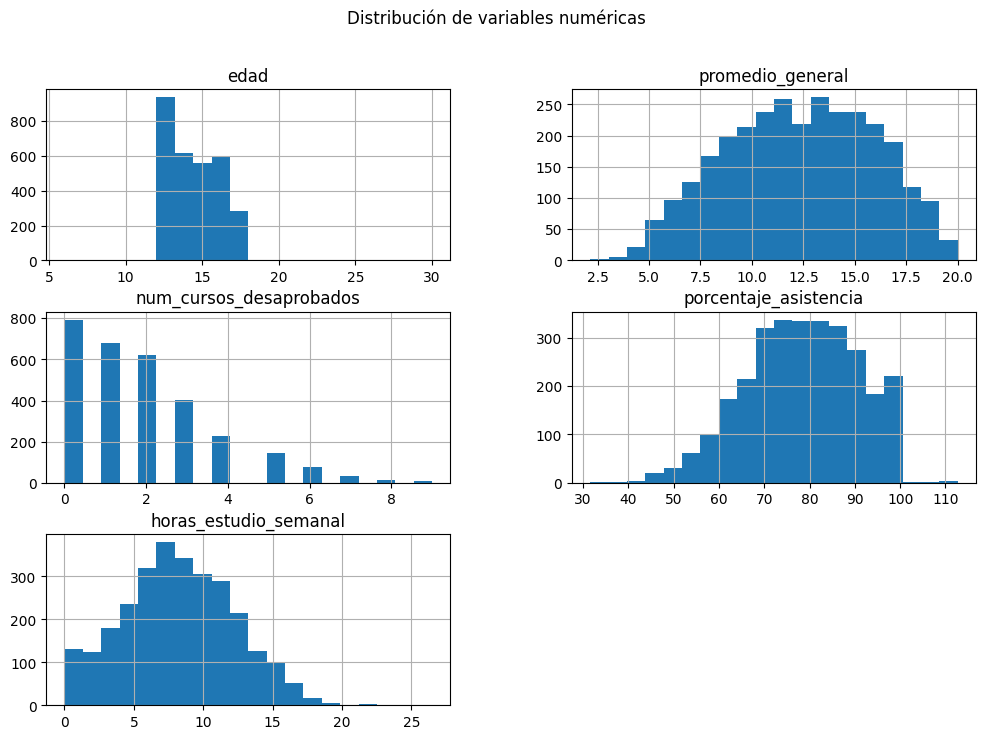

In [79]:
# Histogramas de variables numéricas seleccionadas
num_cols = ['edad', 'promedio_general', 'num_cursos_desaprobados',
            'porcentaje_asistencia', 'horas_estudio_semanal']
df[num_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle('Distribución de variables numéricas')
plt.show()

> Se observan asimetrías en las distribuciones que pueden influir en el modelo.


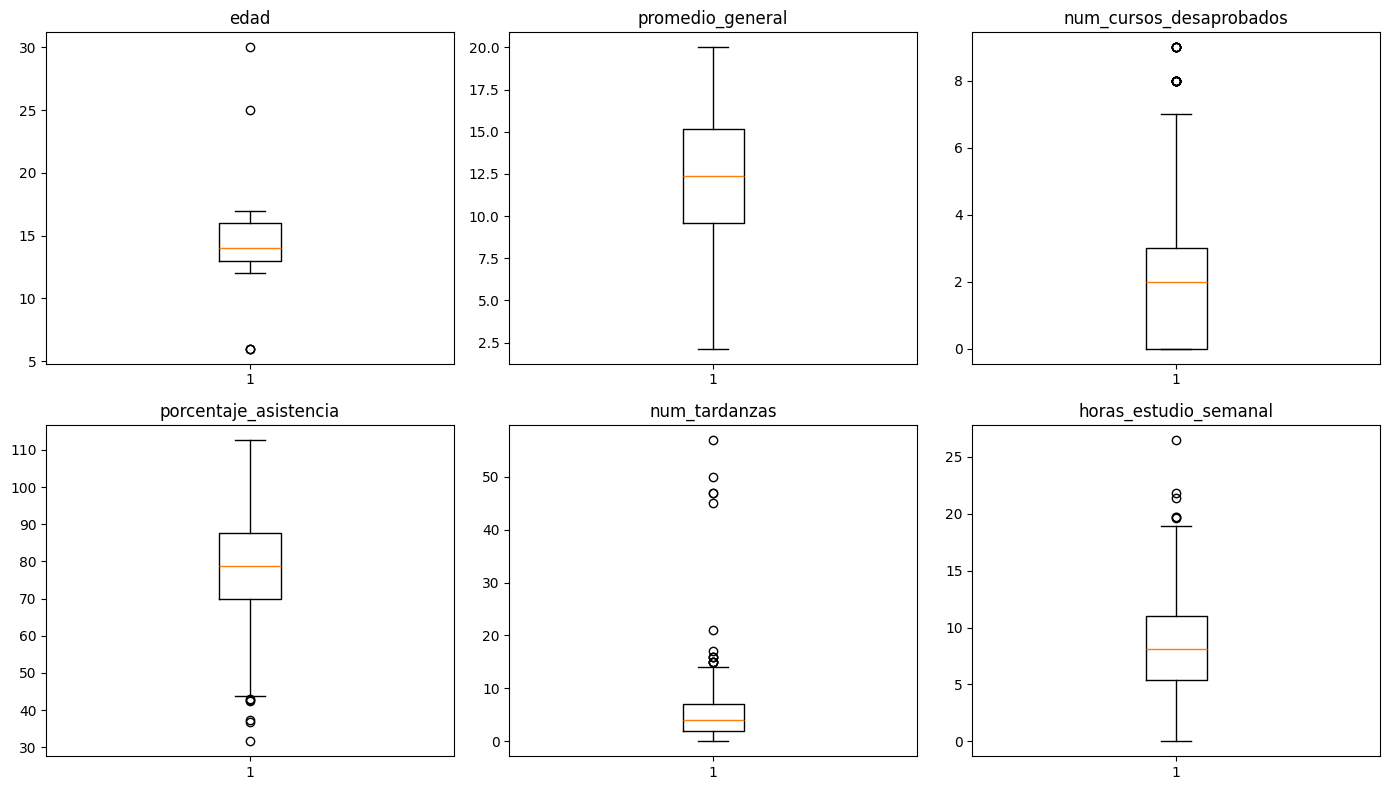

In [80]:
# Boxplots de variables numéricas antes de tratar outliers
num_features = ['edad', 'promedio_general', 'num_cursos_desaprobados',
                'porcentaje_asistencia', 'num_tardanzas', 'horas_estudio_semanal']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, num_features):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()

> Se identifican outliers que serán tratados con el método IQR.


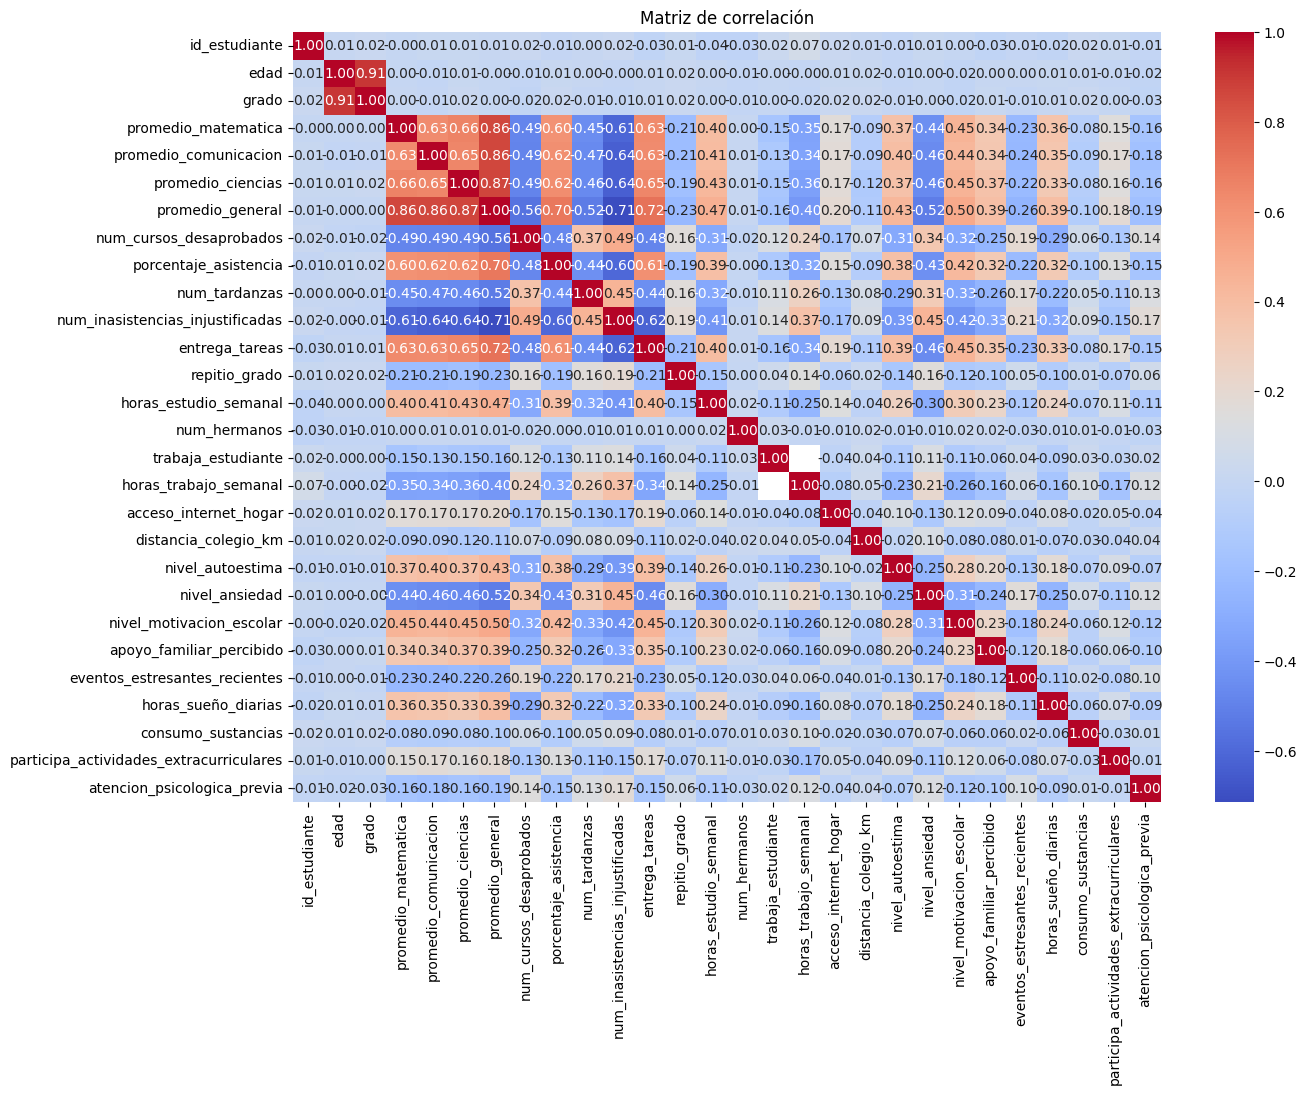

In [81]:
# Matriz de correlación entre variables numéricas
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

> Las variables con mayor correlación con el target ayudarán a la predicción.


# Preprocesamiento de datos


In [82]:
# Reemplazar cadenas vacías por NaN
df = df.replace('', np.nan)

In [83]:
# Imputar valores nulos en numéricas con la mediana
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [84]:
# Imputar valores nulos en categóricas con la moda (excepto target)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if col != 'target':
        df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\yerym\AppData\Local\Temp\ipykernel_26348\207854475.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [85]:
# Tratar outliers con el método del rango intercuartil (IQR)
iqr_cols = ['edad', 'promedio_matematica', 'promedio_comunicacion',
            'promedio_ciencias', 'promedio_general', 'num_cursos_desaprobados',
            'porcentaje_asistencia', 'num_tardanzas', 'num_inasistencias_injustificadas',
            'entrega_tareas', 'horas_estudio_semanal', 'num_hermanos',
            'horas_trabajo_semanal', 'distancia_colegio_km',
            'eventos_estresantes_recientes', 'horas_sueño_diarias']

for col in iqr_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lim_inf, lim_sup)

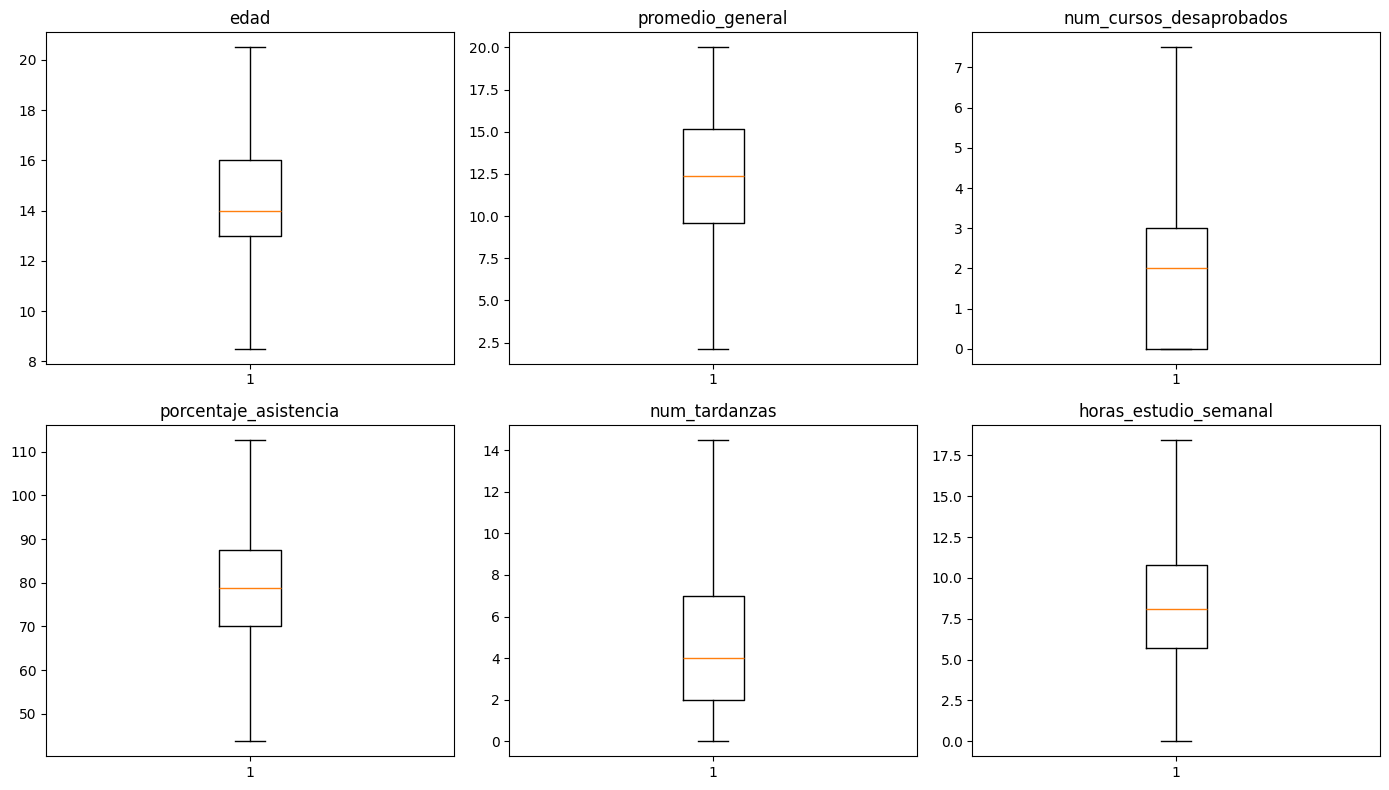

In [86]:
# Boxplots después de tratar outliers
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, num_features):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()

> Los outliers han sido reducidos, mejorando la robustez del modelo.


In [87]:
# Binning de edad en rangos
df['edad_rango'] = pd.cut(df['edad'], bins=[0, 13, 15, 17, 100],
                          labels=['12-13', '14-15', '16-17', '18+'])

# Binning de horas de estudio semanal
df['estudio_rango'] = pd.cut(df['horas_estudio_semanal'], bins=[0, 5, 15, 50],
                             labels=['Pocas', 'Moderadas', 'Muchas'])

In [88]:
# One-Hot Encoding para variables categóricas
cat_to_encode = ['grado', 'tendencia_notas', 'participacion_clase',
                 'genero', 'estructura_familiar', 'nivel_socioeconomico',
                 'nivel_educativo_padres', 'nivel_autoestima', 'nivel_ansiedad',
                 'nivel_motivacion_escolar', 'apoyo_familiar_percibido',
                 'relacion_con_companeros', 'consumo_sustancias',
                 'edad_rango', 'estudio_rango']

df = pd.get_dummies(df, columns=cat_to_encode, drop_first=True)

In [21]:
df.head()

,id_estudiante,edad,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,num_inasistencias_injustificadas,...,apoyo_familiar_percibido_4,apoyo_familiar_percibido_5,relacion_con_companeros_Conflictiva,relacion_con_companeros_Regular,consumo_sustancias_1,edad_rango_14-15,edad_rango_16-17,edad_rango_18+,estudio_rango_Moderadas,estudio_rango_Muchas
0,3169,16.0,10.85,14.06,12.30,13.37,0.0,77.5,6.0,1.0,...,True,False,False,True,False,False,True,False,False,False
1,1163,15.0,18.63,14.59,16.66,17.37,0.0,100.0,1.0,0.0,...,False,False,False,True,False,True,False,False,True,False
2,2517,13.0,20.00,16.54,14.42,16.74,0.0,98.5,2.0,2.0,...,True,False,False,True,False,False,False,False,True,False
3,2318,13.0,16.91,19.40,19.70,18.24,1.0,95.4,1.0,5.0,...,False,False,False,False,False,False,False,False,False,True
4,1686,17.0,17.83,13.27,14.91,15.59,0.0,87.4,2.0,2.0,...,True,False,False,False,False,False,True,False,True,False


# División del train 80% y 20% del test


In [30]:
# Separar características y variable objetivo
X = df.drop(['target', 'id_estudiante'], axis=1)
y = df['target']

In [31]:
# Importar y aplicar división train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [32]:
# Escalar variables con StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modelos de Machine Learning


# Árbol de Decisión


In [33]:
# GridSearchCV para mejores hiperparámetros
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    'max_depth': [3, 5, 7, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information 

In [53]:
# Crear el modelo
from sklearn.tree import DecisionTreeClassifier

print('Mejores parámetros:', grid_dt.best_params_)

model_dt = DecisionTreeClassifier(
    max_depth=grid_dt.best_params_['max_depth'],
    criterion=grid_dt.best_params_['criterion'],
    class_weight='balanced',
    random_state=42
)


Mejores parámetros: {'criterion': 'entropy', 'max_depth': 3}


In [54]:
# Entrenar el modelo
model_dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are 

In [56]:
# Realizar predicciones
y_pred_dt = model_dt.predict(X_test)

In [57]:
# Resultados
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy:", accuracy_dt)
print("\nReporte:\n", classification_report(y_test, y_pred_dt))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.7166666666666667

Reporte:
                         precision    recall  f1-score   support

   Continua_estudiando       0.80      0.82      0.81       239
Necesita_reforzamiento       0.68      0.55      0.61       239
            Suspendido       0.63      0.84      0.72       122

              accuracy                           0.72       600
             macro avg       0.70      0.74      0.71       600
          weighted avg       0.72      0.72      0.71       600


Matriz de confusión:
 [[196  43   0]
 [ 46 132  61]
 [  2  18 102]]


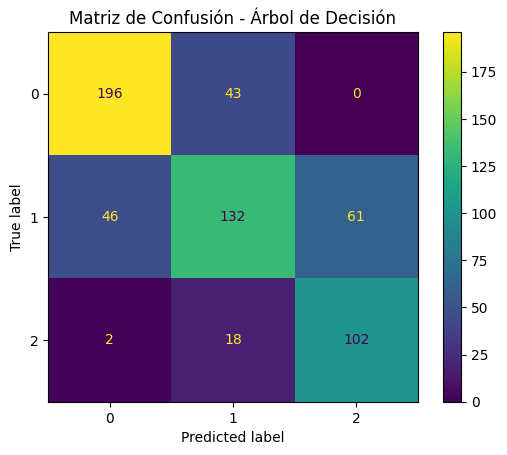

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

# Random Forest


In [59]:
# GridSearchCV para mejores hiperparámetros
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [50, 100, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information p

In [60]:
# Crear el modelo
from sklearn.ensemble import RandomForestClassifier

print('Mejores parámetros:', grid_rf.best_params_)

model_rf = RandomForestClassifier(
    n_estimators=grid_rf.best_params_['n_estimators'],
    max_depth=grid_rf.best_params_['max_depth'],
    class_weight='balanced',
    random_state=42
)

Mejores parámetros: {'max_depth': None, 'n_estimators': 100}


In [61]:
# Entrenar el modelo
model_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [62]:
# Realizar predicciones
y_pred_rf = model_rf.predict(X_test)

In [63]:
# Resultados
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", accuracy_rf)
print("\nReporte:\n", classification_report(y_test, y_pred_rf))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7933333333333333

Reporte:
                         precision    recall  f1-score   support

   Continua_estudiando       0.89      0.83      0.86       239
Necesita_reforzamiento       0.76      0.72      0.74       239
            Suspendido       0.71      0.88      0.78       122

              accuracy                           0.79       600
             macro avg       0.78      0.81      0.79       600
          weighted avg       0.80      0.79      0.79       600


Matriz de confusión:
 [[198  40   1]
 [ 25 171  43]
 [  0  15 107]]


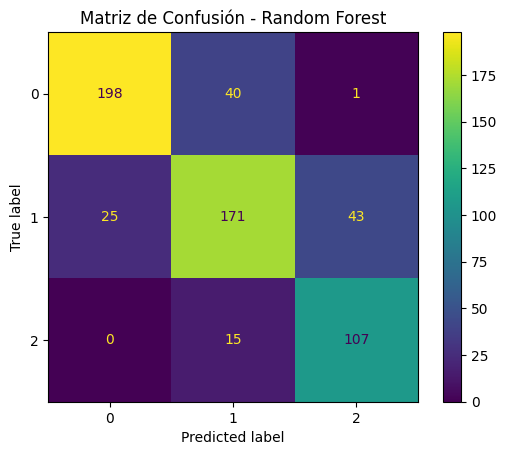

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusión - Random Forest")
plt.show()

# SVM


In [65]:
# GridSearchCV para mejores hiperparámetros
from sklearn.svm import SVC

param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear']
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=5,
    n_jobs=-1
)
grid_svm.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of infor

In [66]:
# Crear el modelo
from sklearn.svm import SVC

print('Mejores parámetros:', grid_svm.best_params_)

model_svm = SVC(
    C=grid_svm.best_params_['C'],
    gamma=grid_svm.best_params_['gamma'],
    kernel=grid_svm.best_params_['kernel'],
    class_weight='balanced',
    random_state=42
)

Mejores parámetros: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


In [67]:
# Entrenar el modelo
model_svm.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


In [68]:
# Realizar predicciones
y_pred_svm = model_svm.predict(X_test)

In [69]:
# Resultados
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy:", accuracy_svm)
print("\nReporte:\n", classification_report(y_test, y_pred_svm))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.7566666666666667

Reporte:
                         precision    recall  f1-score   support

   Continua_estudiando       0.88      0.80      0.84       239
Necesita_reforzamiento       0.71      0.67      0.69       239
            Suspendido       0.64      0.84      0.73       122

              accuracy                           0.76       600
             macro avg       0.75      0.77      0.75       600
          weighted avg       0.77      0.76      0.76       600


Matriz de confusión:
 [[191  46   2]
 [ 24 160  55]
 [  1  18 103]]


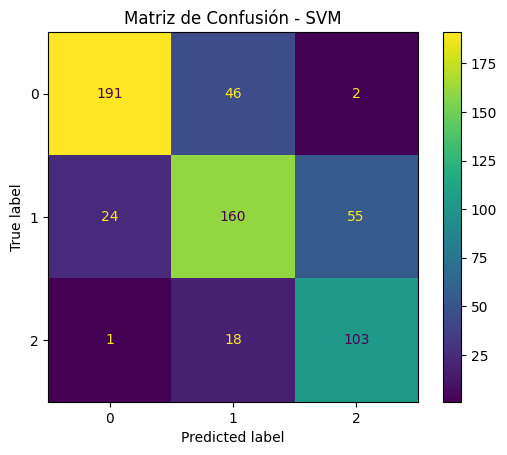

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusión - SVM")
plt.show()

# Cross Validation


In [71]:
from sklearn.model_selection import cross_val_score

cv_scores = {
    'Decision Tree': cross_val_score(model_dt, X_train, y_train, cv=5).mean(),
    'Random Forest': cross_val_score(model_rf, X_train, y_train, cv=5).mean(),
    'SVM': cross_val_score(model_svm, X_train, y_train, cv=5).mean()
}

for modelo, score in cv_scores.items():
    print(f'{modelo}: {score:.4f}')


Decision Tree: 0.7158
Random Forest: 0.7658
SVM: 0.7554


# Comparación Final


In [72]:
print('=== Comparación de Modelos ===')
print(f'Decision Tree:  {accuracy_dt:.4f}')
print(f'Random Forest:  {accuracy_rf:.4f}')
print(f'SVM:            {accuracy_svm:.4f}')

mejor = max([
    ('Decision Tree', accuracy_dt),
    ('Random Forest', accuracy_rf),
    ('SVM', accuracy_svm)
], key=lambda x: x[1])

print(f'\n*** Mejor modelo: {mejor[0]} con accuracy {mejor[1]:.4f} ***')


=== Comparación de Modelos ===
Decision Tree:  0.7167
Random Forest:  0.7933
SVM:            0.7567

*** Mejor modelo: Random Forest con accuracy 0.7933 ***


In [ ]:
df.to_csv('dataset_procesado.csv', index=False)